In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
import pathlib
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline
%load_ext autoreload
%autoreload 2


In [31]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig6_reward_stability')
figdir.mkdir(exist_ok=True, parents=True)

In [25]:
def get_reward_cells_across_days(sess):

    rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
    rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

    if sess.novel_arm == 1: 
        rz_nov = rz_late
        rz_fam = rz_early
    else: 
        rz_nov = rz_early
        rz_fam = rz_late

    pc_mask = sess.fam_place_cell_mask()+sess.nov_place_cell_mask()
    # print(pc_mask.shape)

    nov_mask= sess.trial_info['LR']==sess.novel_arm

    pc_dict = {}
    for align_day in range(6):
        pc_dict[align_day] = {}
    
        day_mask = sess.trial_info['sess_num']==align_day

        tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
        maxpos_nov = np.nanargmax(tmat_nov, axis=0)
        rel_pos_nov = maxpos_nov-rz_nov[0]
        rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]-1))

        tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
        # print(tmat_fam.shape)
        maxpos_fam = np.nanargmax(tmat_fam, axis=0)
        rel_pos_fam = maxpos_fam - rz_fam[0]
        rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]-1))

        # r_cell_mask = rz_cell_fam * rz_cell_nov * (np.abs(rel_pos_fam-rel_pos_nov)<=2)
        r_cell_mask =  (np.abs(rel_pos_fam-rel_pos_nov)<=2) * (maxpos_fam>10) * (maxpos_nov>10)
        
        for day in range(6):
            pc_dict[align_day][day] = {}
            day_mask = sess.trial_info['sess_num']==day
            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    n_mask = nov_mask
                    rz = rz_nov
                else:
                    n_mask = ~nov_mask
                    rz = rz_fam
                    
                day_tmat = np.nanmean(sess.trial_matrices['F_dff'][n_mask*day_mask,:,:][:,:,pc_mask],axis=0)
                pc_dict[align_day][day][ttype] = np.roll(day_tmat[:,r_cell_mask],15-rz[0], axis=0)
    return pc_dict




In [26]:

pc_dict= {}
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    pc_dict[cond] = {}
    for mouse in mice:
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6))
        pc_dict[cond][mouse] = get_reward_cells_across_days(sess)

29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


In [27]:
plot_dict = {}
align_day = 2
for cond, mice in zip(('ctrl', 'ko'),(ctrl_mice, ko_mice)):
    plot_dict[cond]={}
    for ttype in ('fam', 'nov'):
        plot_dict[cond][ttype] = {}
        for day in range(6):

            arr = []

            for mouse in mice:
                arr.append(pc_dict[cond][mouse][align_day][day][ttype])
            plot_dict[cond][ttype][day]= np.hstack(arr)


# sort_tmat = pc_dict[5]['fam']
# sort = np.argsort(np.nanargmax(sort_tmat, axis=0))

# fig, ax = plt.subplots(2,6)
# for i,nov in enumerate(('fam','nov')):
#     for day in range(6):
#         tmat = pc_dict[day][nov]
#         ax[i,day].imshow(tmat[:,sort].T,aspect='auto')

In [28]:
import astropy
import astropy.stats

(537,)
ctrl fam 0 0.3138975212572622
ctrl fam 1 0.4235102225139803
ctrl fam 2 0.9320272040492952
ctrl fam 3 0.4068705063438089
ctrl fam 4 0.42027319030930727
ctrl fam 5 0.24505958481600573
(537,)
ctrl nov 0 0.1657007719746335
ctrl nov 1 0.3008134504377983
ctrl nov 2 0.9393938046294823
ctrl nov 3 0.32771474898356634
ctrl nov 4 0.32820740328756975
ctrl nov 5 0.28593443444972894
(220,)
ko fam 0 0.17270790492416058
ko fam 1 0.44382917709685604
ko fam 2 0.9558492842691155
ko fam 3 0.447224216088572
ko fam 4 0.46388425050363524
ko fam 5 0.3942639805181663
(220,)
ko nov 0 0.003323860821012883
ko nov 1 0.2580429916752494
ko nov 2 0.9548055095223865
ko nov 3 0.3014607575368255
ko nov 4 0.26273983888027097
ko nov 5 0.03708998569656405


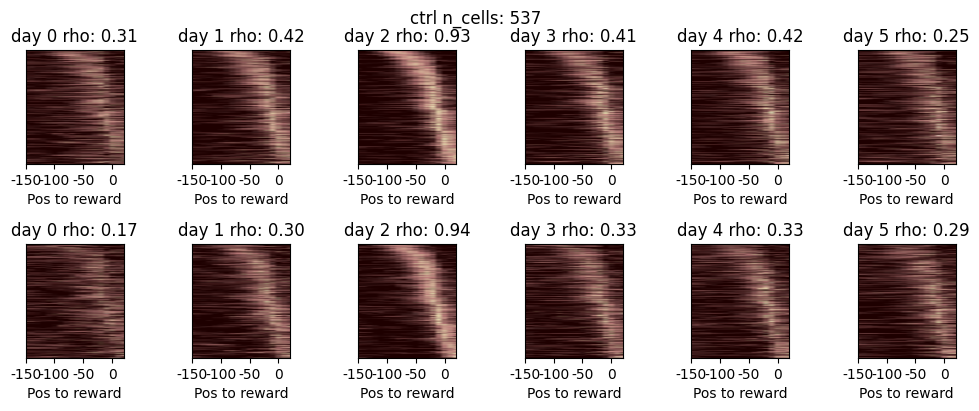

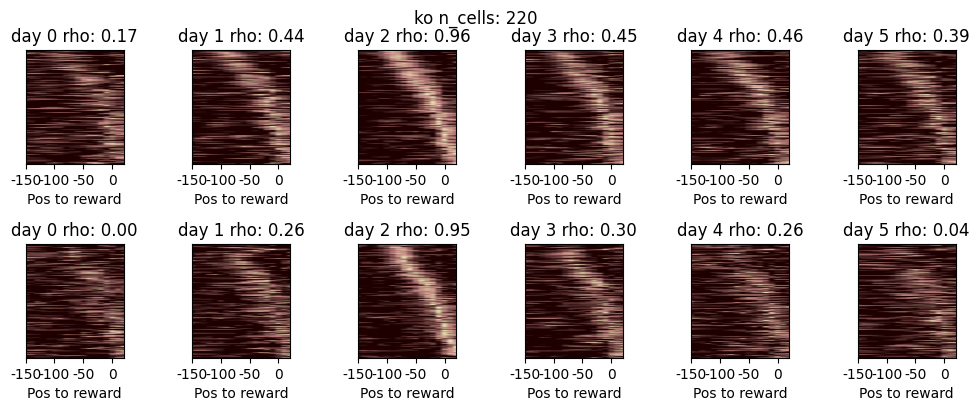

In [36]:
for cond in ('ctrl', 'ko'):
    sort_tmat = plot_dict[cond]['fam'][align_day] + plot_dict[cond]['nov'][align_day]
    sort_tmat = plot_dict[cond]['fam'][align_day] + plot_dict[cond]['nov'][align_day]
    sort_argmax = np.nanargmax(sort_tmat, axis=0)

    sort = np.argsort(sort_argmax)
    n_cells = sort.shape[0]

    fig, ax = plt.subplots(2,6, figsize=[12,4])
    fig.subplots_adjust(wspace=.7, hspace=.7)
    fig.suptitle(f"{cond} n_cells: {n_cells}")
    for i,nov in enumerate(('fam','nov')):
        # sort_tmat = plot_dict[cond][nov][5] #+ plot_dict[cond]['nov'][5]
        # sort = np.argsort(np.nanargmax(sort_tmat, axis=0))
        print(sort.shape)
        for day in range(6):
            tmat = sp.stats.zscore(plot_dict[cond][nov][day],axis=0)

            r = astropy.stats.circcorrcoef(stx.reward_overrep.pos_to_rad(np.nanargmax(tmat, axis=0)), stx.reward_overrep.pos_to_rad(sort_argmax))
            print(cond, nov, day, r)
            ax[i,day].imshow(tmat[:,sort].T,aspect='auto', cmap='pink', vmin=0, vmax=5)
            ax[i,day].set_xlim([0,17])
            
            ax[i,day].set_title(f'day {day} rho: {r:.2f}')
            ax[i,day].set_xticks([0,5,10,15], labels=[-150, -100, -50, 0])
            ax[i,day].set_yticks([])
            ax[i,day].set_xlabel('Pos to reward')


    fig.savefig(figdir / f'pop_reward_cells_{cond}_day{align_day}_sort.pdf')